# Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings

In [2]:
# Turn off warnings
warnings.filterwarnings('ignore')

In [3]:
# Load data
df = pd.read_csv('../data/data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


# Data Quick Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [5]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [6]:
df.isna().sum() # No missing value found

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [7]:
# We have some 0 value on price, bedrooms, bathrooms. We take that as data entry error. 
# We will drop the 0 price in df, and will drop rest of those before building model.

zero_counts_per_column = (df == 0).sum()
print("Count of zero values per column in DataFrame 'df':")
print(zero_counts_per_column)

Count of zero values per column in DataFrame 'df':
date                0
price              49
bedrooms            2
bathrooms           2
sqft_living         0
sqft_lot            0
floors              0
waterfront       4567
view             4140
condition           0
sqft_above          0
sqft_basement    2745
yr_built            0
yr_renovated     2735
street              0
city                0
statezip            0
country             0
dtype: int64


In [8]:
# Remove all 0 price variables
df = df[df['price'] > 0]

# EDA

## House Price Distribution


Price Tier Counts:
price_bin
200–400K    1567
400–600K    1417
600–800K     718
800K–1M      320
1–2M         293
<200K        189
>2M           47
Name: count, dtype: int64


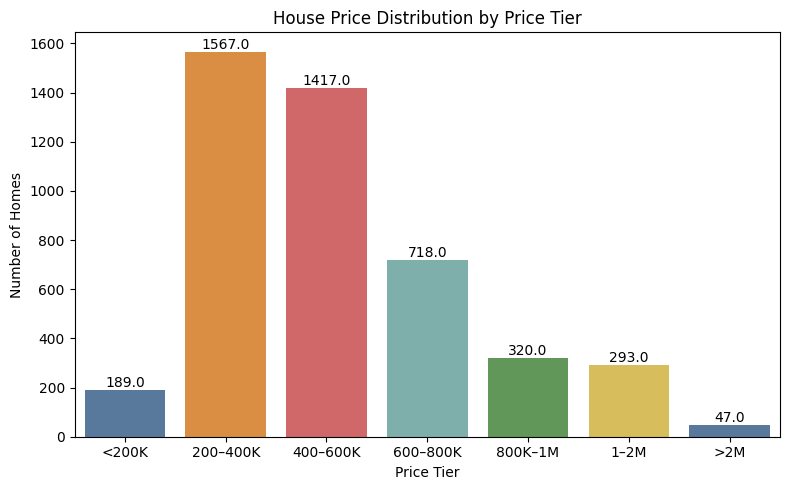

In [9]:
# df_eda is only for visualization
df_eda = df.copy()

# Define price bins
bins = [0, 200000, 400000, 600000, 800000, 1000000, 2000000, df_eda['price'].max()]
labels = ['<200K', '200–400K', '400–600K', '600–800K', '800K–1M', '1–2M', '>2M']

# Apply binning to df_eda only
df_eda['price_bin'] = pd.cut(df_eda['price'], bins=bins, labels=labels)

# Reorder bins in correct order
df_eda['price_bin'] = df_eda['price_bin'].cat.reorder_categories(labels, ordered=True)

# Print value counts
value_counts = df_eda['price_bin'].value_counts()
print("\nPrice Tier Counts:")
print(value_counts)

# Visualize with annotation
plt.figure(figsize=(8,5))
palette_t = [
    "#4E79A7",
    "#F28E2B",
    "#E15759",
    "#76B7B2",
    "#59A14F",
    "#EDC948"
]
ax = sns.countplot(x=df_eda['price_bin'], palette=palette_t)
plt.title("House Price Distribution by Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Number of Homes")

# Add labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

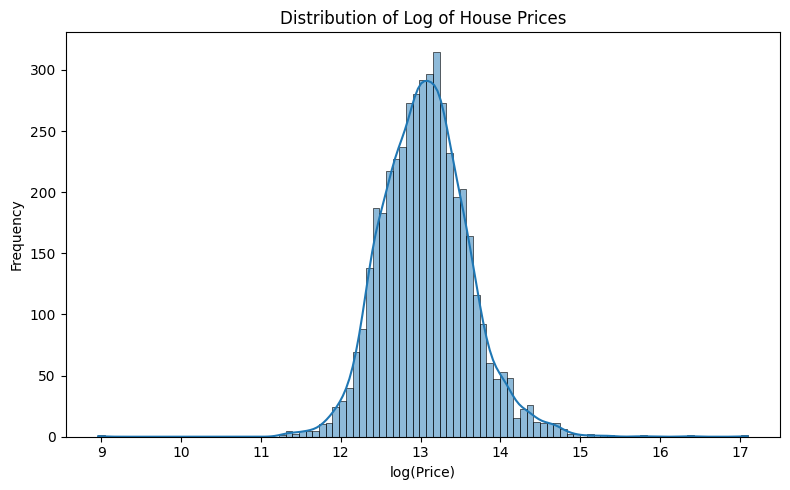

In [10]:
# Histogram of Log-Price
df_eda['log_price'] = np.log(df_eda['price'])

plt.figure(figsize=(8,5))
sns.histplot(df_eda['log_price'], kde=True, palette=palette_t)
plt.title("Distribution of Log of House Prices")
plt.xlabel("log(Price)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [11]:
# Describe Statistics
print('Descriptive Statistics')
desc_vars = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
               'floors', 'sqft_above', 'sqft_basement']
print(df_eda[desc_vars].describe().round(2))

# Additional Statistics
print(f'\nPrice Statistics')
print(f"Mean: ${df_eda['price'].mean():,.0f}")
print(f"Median: ${df_eda['price'].median():,.0f}")
print(f"Standard Deviation: ${df_eda['price'].std():,.0f}")
print(f"Skewness: {df_eda['price'].skew():,.2f}")
print(f"Range: ${df_eda['price'].min():,.0f} to ${df_eda['price'].max():,.0f}")

Descriptive Statistics
             price  bedrooms  bathrooms  sqft_living    sqft_lot   floors  \
count      4551.00   4551.00    4551.00      4551.00     4551.00  4551.00   
mean     557905.90      3.39       2.16      2132.37    14835.28     1.51   
std      563929.87      0.90       0.78       955.95    35964.08     0.54   
min        7800.00      0.00       0.00       370.00      638.00     1.00   
25%      326264.29      3.00       1.75      1460.00     5000.00     1.00   
50%      465000.00      3.00       2.25      1970.00     7680.00     1.50   
75%      657500.00      4.00       2.50      2610.00    10978.00     2.00   
max    26590000.00      9.00       8.00     13540.00  1074218.00     3.50   

       sqft_above  sqft_basement  
count     4551.00        4551.00  
mean      1822.22         310.15  
std        854.45         461.99  
min        370.00           0.00  
25%       1190.00           0.00  
50%       1590.00           0.00  
75%       2300.00         600.00  
max

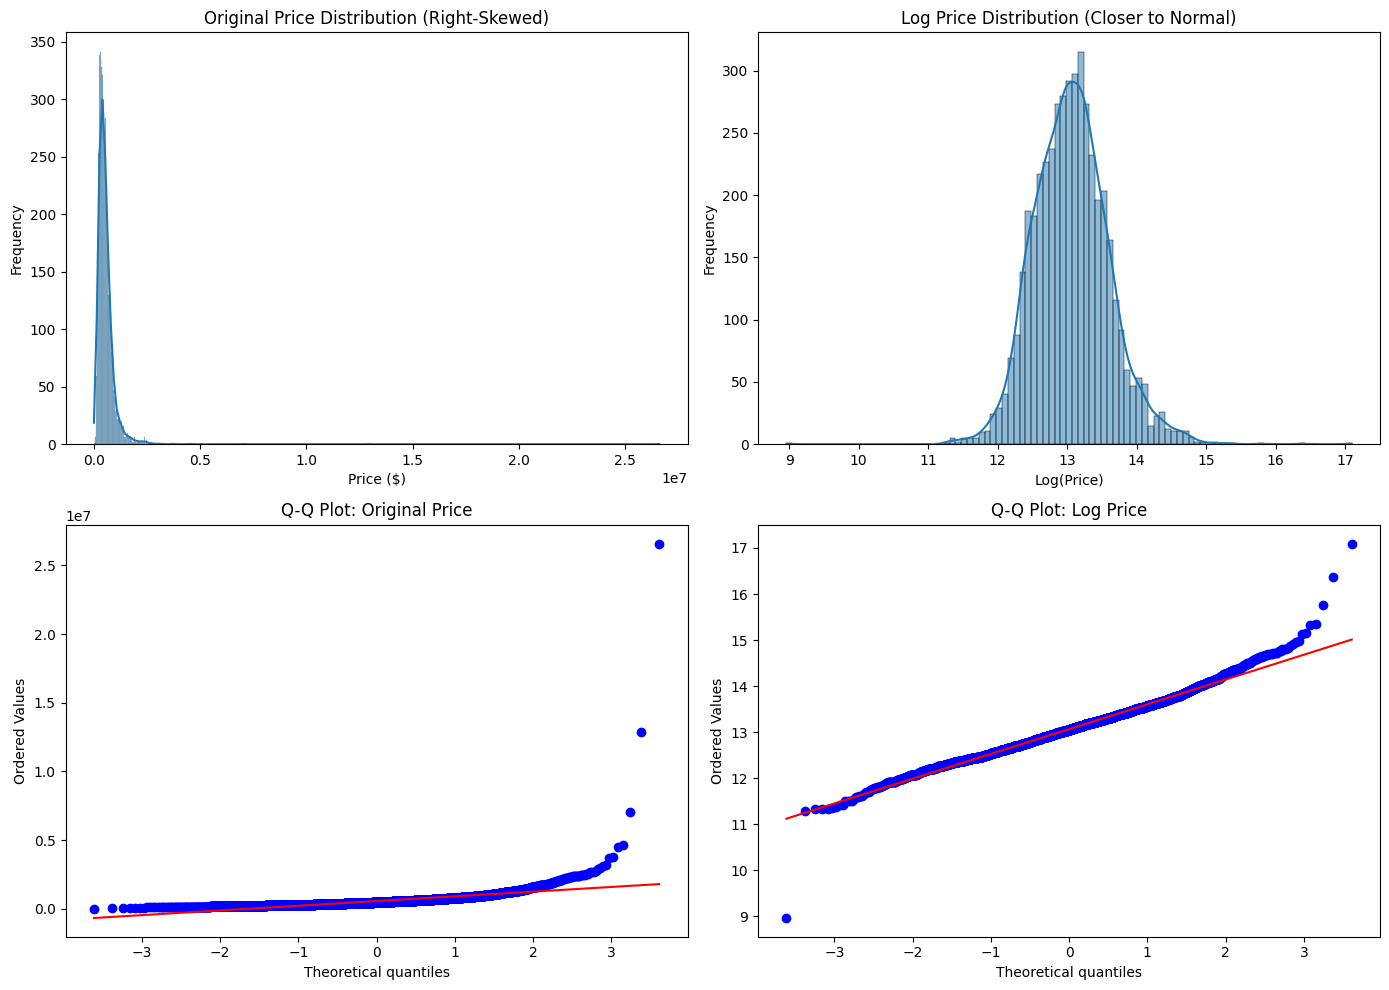

In [12]:
# Visualization: Price distribution before and after log transformation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original Price Distribution
sns.histplot(df_eda['price'], kde=True, palette=palette_t, ax=axes[0, 0])
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Original Price Distribution (Right-Skewed)')

# Log-transformed price distribution
sns.histplot(df_eda['log_price'], kde=True, palette=palette_t, ax=axes[0, 1])
axes[0, 1].set_xlabel('Log(Price)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Log Price Distribution (Closer to Normal)')

# Q-Q plot for original price
stats.probplot(df_eda['price'], dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Original Price')

# Q-Q plot for log price
stats.probplot(df_eda['log_price'], dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Log Price')

# Cosmetic Procedures
plt.tight_layout()
plt.show()

## Correlation Analysis

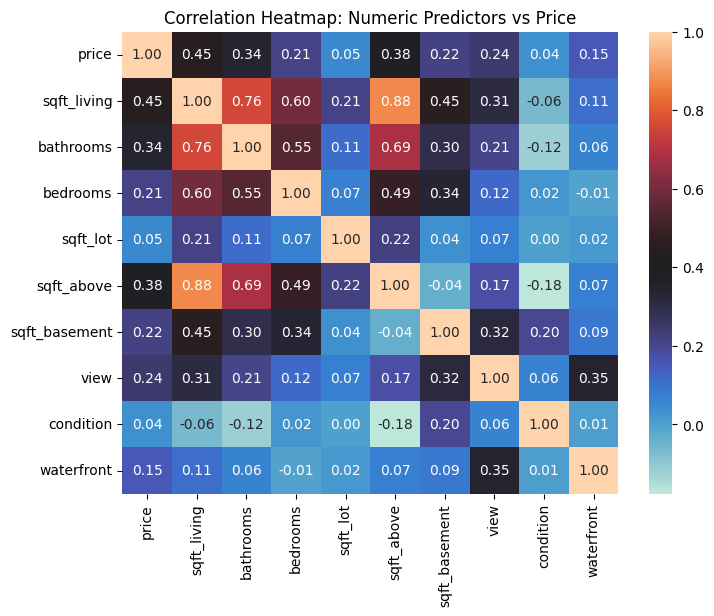

In [13]:
# Build a correlation matrix
num_vars = ['price','sqft_living','bathrooms','bedrooms','sqft_lot',
            'sqft_above','sqft_basement','view','condition','waterfront']

plt.figure(figsize=(8,6))
sns.heatmap(df_eda[num_vars].corr(), annot=True, cmap='icefire', fmt=".2f")
plt.title("Correlation Heatmap: Numeric Predictors vs Price")
plt.show()

In [14]:
# Print High Correlation Pairs
correlation_matrix = df_eda[num_vars].corr()
print('\nHigh Correlation Detected (|r| > 0.7):\n')
high_correlation = np.where(np.abs(correlation_matrix) > 0.7) # np.where: Returns the index where the condition is True
high_correlation_list = [(correlation_matrix.index[x], correlation_matrix.columns[y], correlation_matrix.iloc[x, y])
                            for x, y in zip(*high_correlation) if x != y and x < y]
for var1, var2, corr in high_correlation_list:
    print(f"{var1} -- {var2}: {corr:.3f}")


High Correlation Detected (|r| > 0.7):

sqft_living -- bathrooms: 0.757
sqft_living -- sqft_above: 0.876


## Price vs. Living Space
- The relationship looks linear: the larger the living area, the higher the price.
- A few extreme prices look suspicious.

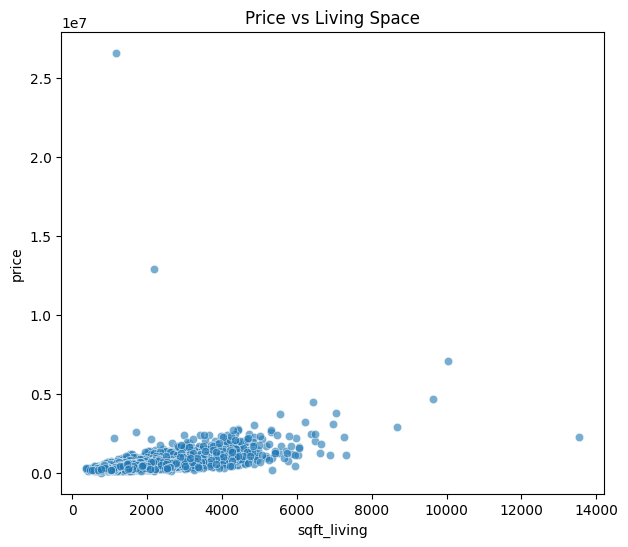

In [15]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=df_eda['sqft_living'], y=df['price'], alpha=0.6)
plt.title("Price vs Living Space")
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.show()

## Prices vs. Above-Ground Sqft
- Same pattern as living area.

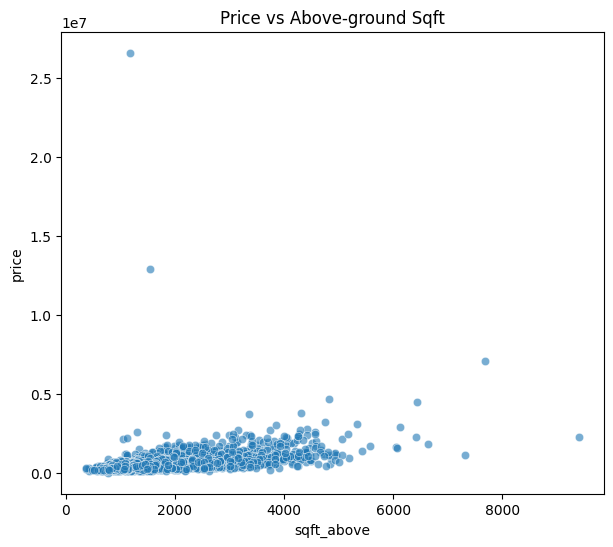

In [16]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=df_eda['sqft_above'], y=df_eda['price'], alpha=0.6)
plt.title("Price vs Above-ground Sqft")
plt.show()


## Price vs Basement Area

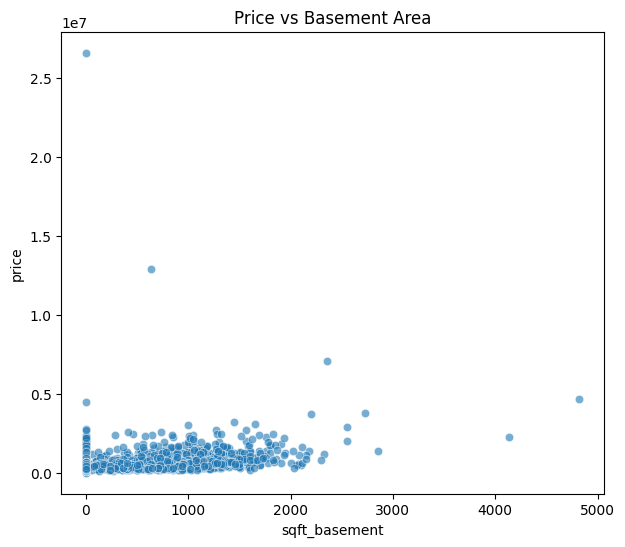

In [17]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=df_eda['sqft_basement'], y=df_eda['price'], alpha=0.6)
plt.title("Price vs Basement Area")
plt.show()

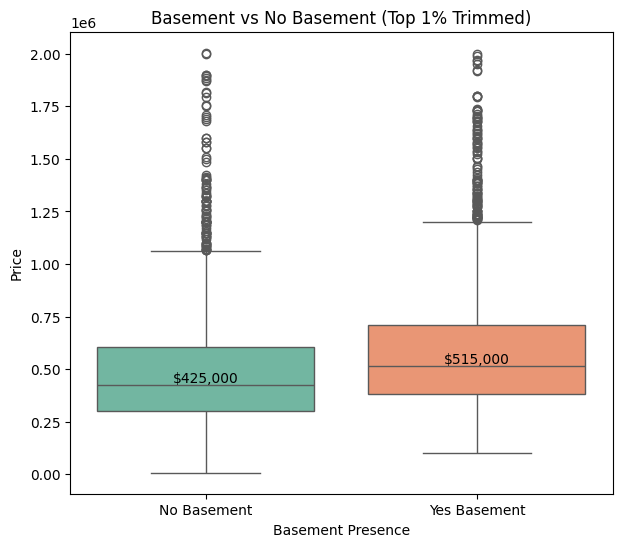

Median price comparison:
basement_present
No Basement     425000.0
Yes Basement    525000.0
Name: price, dtype: float64


In [18]:
df_eda['basement_present'] = np.where(df_eda['sqft_basement'] > 0,'Yes Basement', 'No Basement')

# Trim top 1% most expensive homes JUST for visualization
q99 = df_eda['price'].quantile(0.99)
df_eda_trim = df_eda[df_eda['price'] <= q99]

plt.figure(figsize=(7,6))
ax = sns.boxplot(x='basement_present', y='price', data=df_eda_trim, palette="Set2")
plt.title("Basement vs No Basement (Top 1% Trimmed)")
plt.xlabel("Basement Presence")
plt.ylabel("Price")

# Add median labels
medians = df_eda_trim.groupby('basement_present')['price'].median()
for i, (label, median) in enumerate(medians.items()):
    ax.text(i, median, f"${median:,.0f}", ha='center', va='bottom', fontsize=10)

plt.show()
print("Median price comparison:")
print(df_eda.groupby('basement_present')['price'].median())

## Price by Number of Bedrooms
- Median price rises from 1 to 4 bedrooms, then levels off. Bedroom count overlaps heavily with living area.

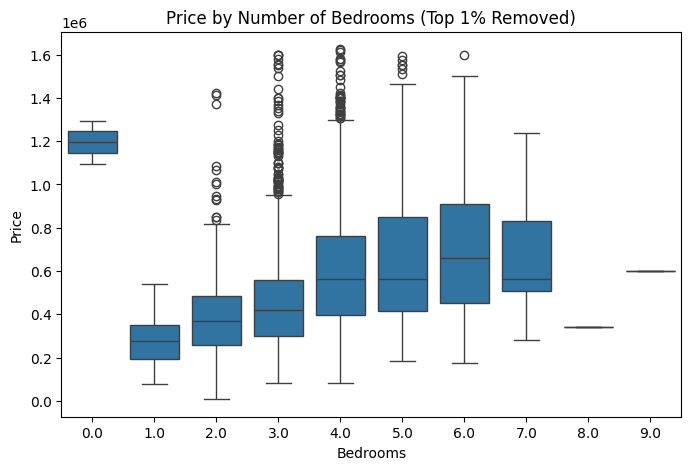

Median price by number of bedrooms (top 1% trimmed):
bedrooms
0.0    $1,195,324
1.0      $275,000
2.0      $370,000
3.0      $420,000
4.0      $565,000
5.0      $565,000
6.0      $662,500
7.0      $565,000
8.0      $340,000
9.0      $599,999
Name: price, dtype: object


In [19]:
# trim top 1% expensive homes for plot only
p99 = df_eda_trim['price'].quantile(0.99)
df_eda_trim = df_eda_trim[df_eda_trim['price'] <= p99]

plt.figure(figsize=(8,5))
sns.boxplot(x='bedrooms', y='price', data=df_eda_trim)
plt.title("Price by Number of Bedrooms (Top 1% Removed)")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()
print("Median price by number of bedrooms (top 1% trimmed):")
median_prices = df_eda_trim.groupby('bedrooms')['price'].median()
print(median_prices.apply(lambda x: f"${x:,.0f}"))

In [20]:
df_eda_trim['bedrooms'].value_counts()

bedrooms
3.0    2008
4.0    1478
2.0     560
5.0     307
6.0      54
1.0      37
7.0      11
0.0       2
9.0       1
8.0       1
Name: count, dtype: int64

In [21]:
df_eda_trim.loc[df_eda_trim['bedrooms'] == 0, ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors', 'yr_built', 'yr_renovated', 'city']]

,price,bedrooms,bathrooms,sqft_living,floors,yr_built,yr_renovated,city
2365,1095000.0,0.0,0.0,3064,3.5,1990,2009,Seattle
3209,1295648.0,0.0,0.0,4810,2.0,1990,2009,Redmond


## Price vs Living Area

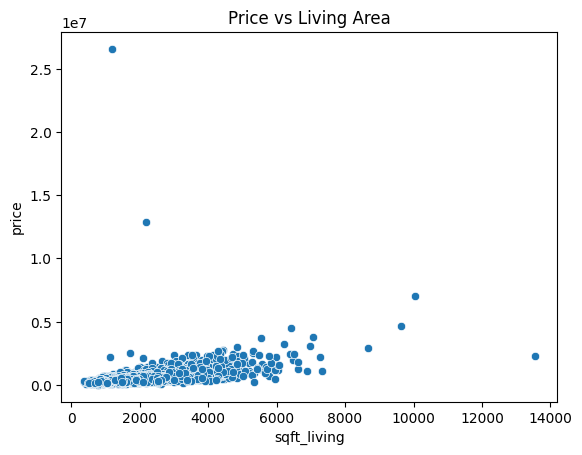

In [22]:
sns.scatterplot(x=df['sqft_living'], y=df['price'])
plt.title("Price vs Living Area")
plt.show()


## Price by Bathroom Category

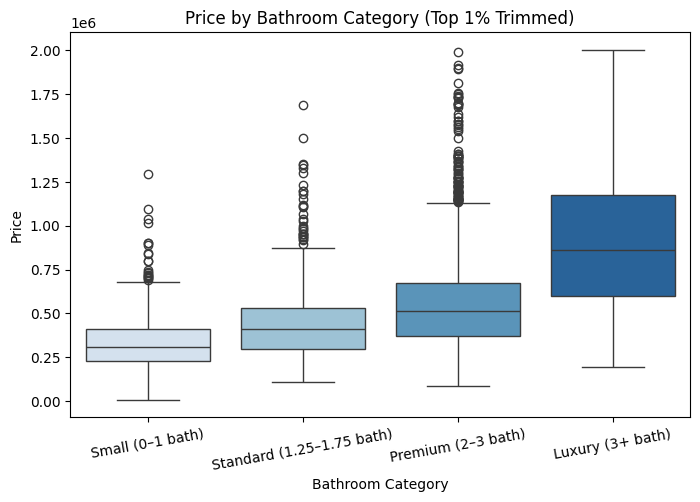

Median prices by bathroom category (ordered):
bath_cat
Luxury (3+ bath)             $860,000
Premium (2–3 bath)           $513,000
Standard (1.25–1.75 bath)    $409,975
Small (0–1 bath)             $307,000
Name: price, dtype: object


In [23]:
def bathroom_tier(b):
    if b <= 1.0:
        return "Small (0–1 bath)"
    elif b <= 1.75:   # expanded standard tier logic
        return "Standard (1.25–1.75 bath)"
    elif b <= 3.0:
        return "Premium (2–3 bath)"
    else:
        return "Luxury (3+ bath)"

df_eda['bath_cat'] = df_eda['bathrooms'].apply(bathroom_tier)

order = [
     "Small (0–1 bath)",
    "Standard (1.25–1.75 bath)",
    "Premium (2–3 bath)",
     "Luxury (3+ bath)"
]

p99 = df_eda['price'].quantile(0.99)
df_eda_trim = df_eda[df_eda['price'] <= p99]

# Compute medians per tier
median_tiers = df_eda_trim.groupby('bath_cat')['price'].median()

plt.figure(figsize=(8,5))
ax = sns.boxplot(x='bath_cat', y='price',
                 data=df_eda_trim,
                 order=order,
                 palette="Blues")

plt.title("Price by Bathroom Category (Top 1% Trimmed)")
plt.xlabel("Bathroom Category")
plt.ylabel("Price")
plt.xticks(rotation=10)
plt.show()

# Print median table
order_2 = [
    "Luxury (3+ bath)",
    "Premium (2–3 bath)",
    "Standard (1.25–1.75 bath)",
    "Small (0–1 bath)"
]

median_tiers_sorted = median_tiers.reindex(order_2)
print("Median prices by bathroom category (ordered):")
print(median_tiers_sorted.apply(lambda x: f"${x:,.0f}"))

## Price: Waterfront vs Non-Waterfront

In [24]:
df_eda['waterfront'].unique()

array([0, 1])

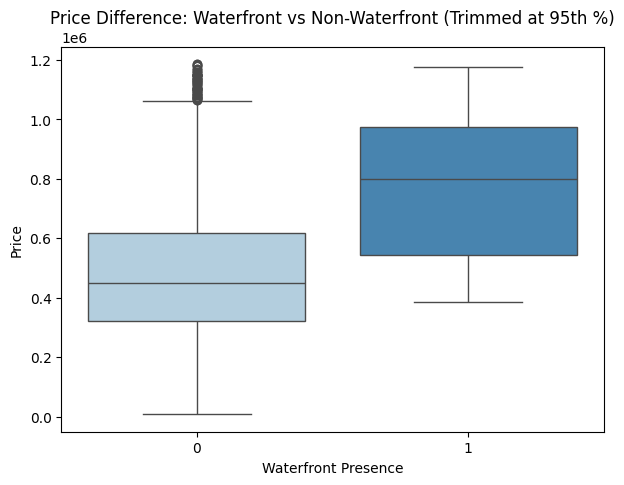

Median price by waterfront category:
waterfront
0      $464,000
1    $1,072,500
Name: price, dtype: object


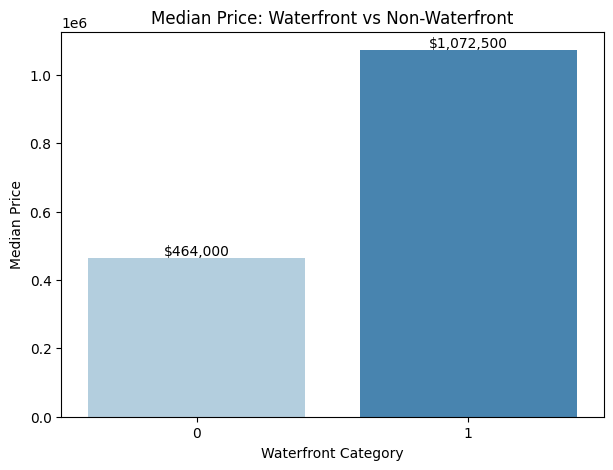

In [25]:
price_cap = df_eda['price'].quantile(0.95)
df_trimmed = df_eda[df_eda['price'] <= price_cap]

plt.figure(figsize=(7,5))
sns.boxplot(x=df_trimmed['waterfront'], y=df_trimmed['price'], palette="Blues")
plt.title("Price Difference: Waterfront vs Non-Waterfront (Trimmed at 95th %)")
plt.xlabel("Waterfront Presence")
plt.ylabel("Price")
plt.show()

waterfront_median = df_eda.groupby("waterfront")["price"].median()
print("Median price by waterfront category:")
print(waterfront_median.apply(lambda x: f"${x:,.0f}"))
plt.figure(figsize=(7,5))
ax = sns.barplot(x=waterfront_median.index, y=waterfront_median.values, palette="Blues")

plt.title("Median Price: Waterfront vs Non-Waterfront")
plt.xlabel("Waterfront Category")
plt.ylabel("Median Price")

# Annotate values
for i, v in enumerate(waterfront_median.values):
    ax.text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=10)

plt.show()

## Price by Scenic View Rating

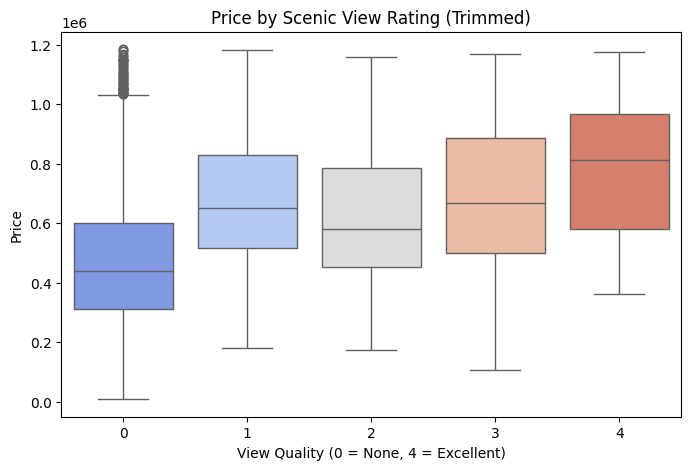

Median price by view level:
view
0    $439,000
1    $650,000
2    $580,000
3    $668,000
4    $812,650
Name: price, dtype: object


In [26]:
price_cap = df_eda['price'].quantile(0.95)
df_trimmed = df_eda[df_eda['price'] <= price_cap]

plt.figure(figsize=(8,5))
sns.boxplot(x=df_trimmed['view'], y=df_trimmed['price'], palette="coolwarm")
plt.title("Price by Scenic View Rating (Trimmed)")
plt.xlabel("View Quality (0 = None, 4 = Excellent)")
plt.ylabel("Price")
plt.show()
median_view = df_trimmed.groupby('view')['price'].median()
print("Median price by view level:")
print(median_view.apply(lambda x: f"${x:,.0f}"))

## Price by House Condition Rating

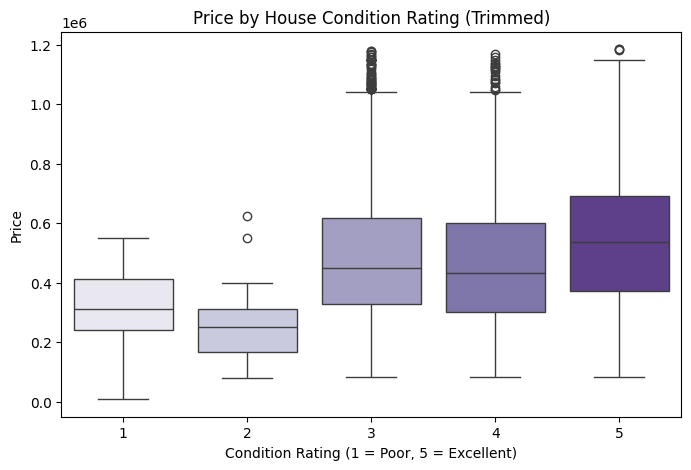

Median price by house condition:
condition
1    $310,000
2    $250,000
3    $450,593
4    $433,000
5    $537,250
Name: price, dtype: object


In [27]:
price_cap = df_eda['price'].quantile(0.95)
df_trimmed = df_eda[df_eda['price'] <= price_cap]
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df_trimmed['condition'],
    y=df_trimmed['price'],
    palette="Purples"
)

plt.title("Price by House Condition Rating (Trimmed)")
plt.xlabel("Condition Rating (1 = Poor, 5 = Excellent)")
plt.ylabel("Price")
plt.show()

median_cond = df_trimmed.groupby('condition')['price'].median()
print("Median price by house condition:")
print(median_cond.apply(lambda x: f"${x:,.0f}"))

## Price Premium: Renovated vs Non-Renovated Homes

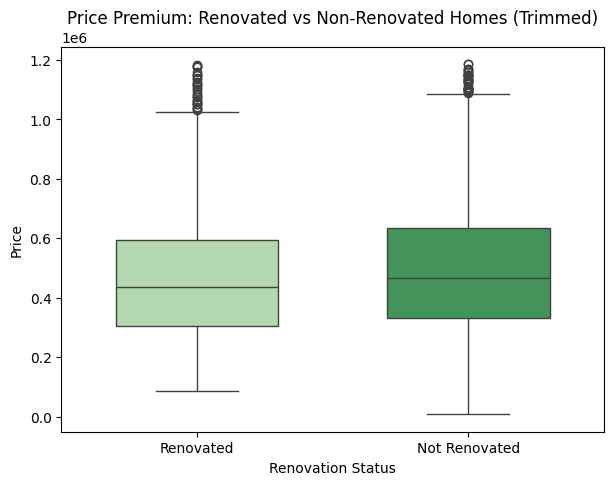

Median price comparison:
renovated_cat
Not Renovated    $464,750
Renovated        $436,500
Name: price, dtype: object


In [28]:
df_eda['renovated_flag'] = df_eda['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
df_eda['renovated_cat'] = df_eda['renovated_flag'].map({0:"Not Renovated", 1:"Renovated"})
df_eda = df_eda.drop(columns = ['renovated_flag'], axis =1)
price_cap = df_eda['price'].quantile(0.95)
df_trimmed = df_eda[df_eda['price'] <= price_cap]

plt.figure(figsize=(7,5))
sns.boxplot(
    x=df_trimmed['renovated_cat'],
    y=df_trimmed['price'],
    palette="Greens",
    width=0.6
)

plt.title("Price Premium: Renovated vs Non-Renovated Homes (Trimmed)")
plt.xlabel("Renovation Status")
plt.ylabel("Price")
plt.show()

median_reno = df_trimmed.groupby('renovated_cat')['price'].median()
print("Median price comparison:")
print(median_reno.apply(lambda x: f"${x:,.0f}"))

## Price Differences Across Construction Eras

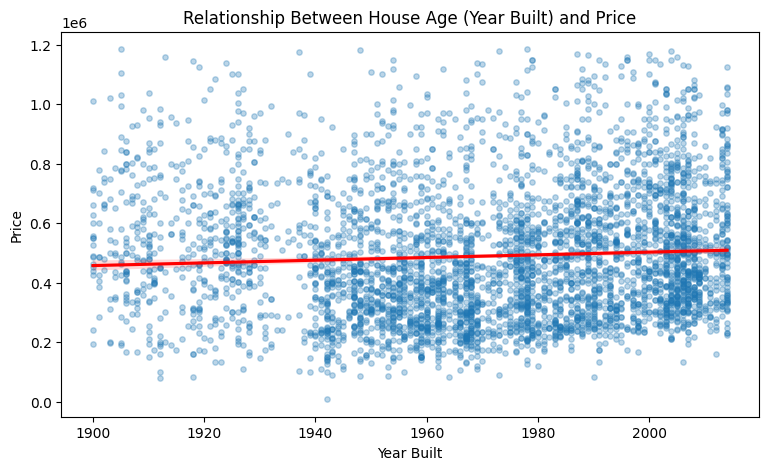

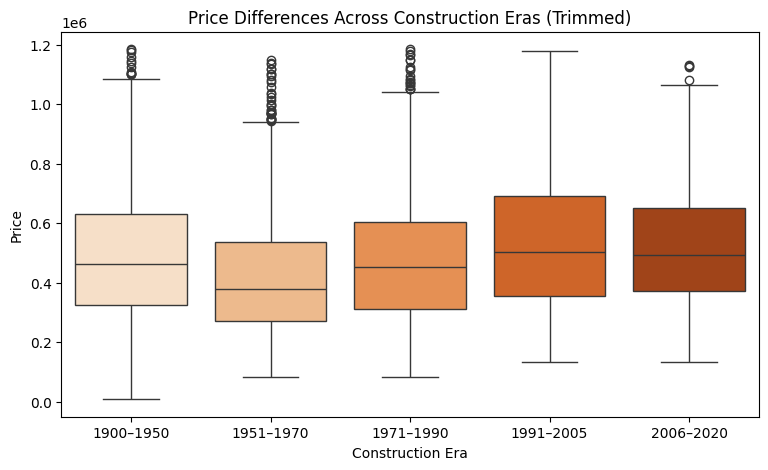

Median prices by construction era:
era_built
1900–1950    $462,000
1951–1970    $380,000
1971–1990    $451,250
1991–2005    $504,000
2006–2020    $494,408
Name: price, dtype: object


In [29]:
price_cap = df_eda['price'].quantile(0.95)
df_trimmed = df_eda[df_eda['price'] <= price_cap]

plt.figure(figsize=(9,5))
sns.regplot(
    x=df_trimmed['yr_built'],
    y=df_trimmed['price'],
    scatter_kws={'alpha':0.3, 's':15},
    line_kws={'color':'red'}
)

plt.title("Relationship Between House Age (Year Built) and Price")
plt.xlabel("Year Built")
plt.ylabel("Price")
plt.show()

bins = [1900, 1950, 1970, 1990, 2005, 2020]
labels = ["1900–1950", "1951–1970", "1971–1990", "1991–2005", "2006–2020"]

df_trimmed["era_built"] = pd.cut(df_trimmed['yr_built'], bins=bins, labels=labels)
plt.figure(figsize=(9,5))
sns.boxplot(
    x=df_trimmed['era_built'],
    y=df_trimmed['price'],
    palette="Oranges"
)

plt.title("Price Differences Across Construction Eras (Trimmed)")
plt.xlabel("Construction Era")
plt.ylabel("Price")
plt.show()

median_era = df_trimmed.groupby("era_built")['price'].median()
print("Median prices by construction era:")
print(median_era.apply(lambda x: f"${x:,.0f}"))

## Price Differences Across Lot Size Categories

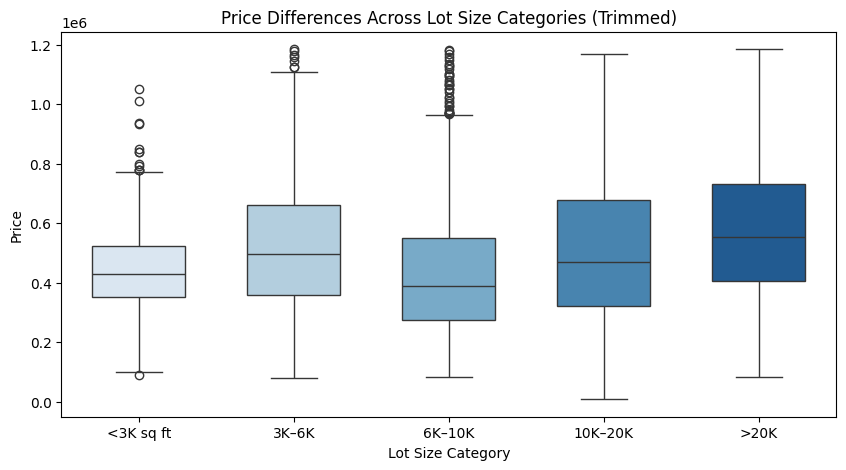

In [30]:
lot_bins = [0, 3000, 6000, 10000, 20000, df_eda['sqft_lot'].max()]
lot_labels = [
    "<3K sq ft",
    "3K–6K",
    "6K–10K",
    "10K–20K",
    ">20K"
]

df_eda['lot_bin'] = pd.cut(df_eda['sqft_lot'], bins=lot_bins, labels=lot_labels)
price_cap = df_eda['price'].quantile(0.95)
df_trimmed = df_eda[df_eda['price'] <= price_cap]

plt.figure(figsize=(10,5))
sns.boxplot(
    x=df_trimmed['lot_bin'],
    y=df_trimmed['price'],
    palette="Blues",
    width=0.6
)

plt.title("Price Differences Across Lot Size Categories (Trimmed)")
plt.xlabel("Lot Size Category")
plt.ylabel("Price")
plt.show()

# Modeling

In [31]:
# Prepare for modeling dataframe
df_model = df.copy()
df_model = df.drop(columns=['sqft_above','date','street','city','statezip','country'])
df_model['log_price'] = np.log(df_model['price'] + 1)

In [32]:
# See where are the 0 values.
zero_counts = (df_model == 0).sum()
print("Count of zero values per variable:\n")
for col, val in zero_counts.items():
    print(f"{col:<20}  {val}")

Count of zero values per variable:

price                 0
bedrooms              2
bathrooms             2
sqft_living           0
sqft_lot              0
floors                0
waterfront            4521
view                  4103
condition             0
sqft_basement         2718
yr_built              0
yr_renovated          2706
log_price             0


In [33]:
# Clean data and Feature engineering
df_model = df_model[df_model['bathrooms'] != 0]
df_model = df_model[df_model['bedrooms'] != 0]
df_model['renovated_flag'] = (df_model['yr_renovated'] > 0).astype(int)
df_model['basement_present'] = (df_model['sqft_basement'] > 0).astype(int)

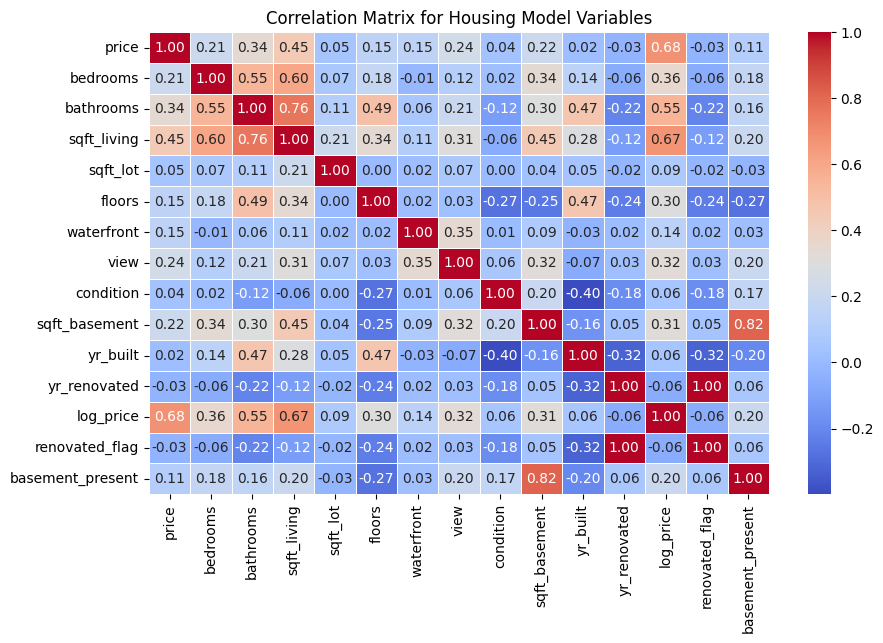

In [34]:
# Build a correlation matrix
df_corr = df_model.select_dtypes(include=['int64', 'float64'])
corr_matrix = df_corr.corr()
corr_matrix.head()
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,          # show correlation values
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix for Housing Model Variables")
plt.show()

In [35]:
# Print High Correlation Pairs
print('\nHigh Correlation Detected (|r| > 0.7):\n')
high_correlation = np.where(np.abs(corr_matrix) > 0.7) # np.where: Returns the index where the condition is True
high_correlation_list = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y])
                            for x, y in zip(*high_correlation) if x != y and x < y]
for var1, var2, corr in high_correlation_list:
    print(f"{var1} -- {var2}: {corr:.3f}")


High Correlation Detected (|r| > 0.7):

bathrooms -- sqft_living: 0.762
sqft_basement -- basement_present: 0.818
yr_renovated -- renovated_flag: 1.000


In [36]:
# Drop one of high correlation features
df_model = df_model.drop(columns=['yr_renovated','sqft_basement'])

In [37]:
# Set X matrix and Y vector
df_model['log_price'] = np.log(df_model['price'])
X = df_model.drop(columns=['price', 'log_price'])  # predictors
y = df_model['log_price']

# Add a constant coefficient to X matrix
X = sm.add_constant(X)

# Fit X and y to the OLS model and Print summary
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     454.8
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        19:57:51   Log-Likelihood:                -1982.2
No. Observations:                4549   AIC:                             3988.
Df Residuals:                    4537   BIC:                             4065.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               18.5464      0.518  

In [38]:
### Calculate VIF for every features to every features to see if there is a multicollinearity ###

# Import necessary library
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Copy your modeling data
df_vif = df_model.copy()

# Drop non-numeric & drop target
df_vif = df_vif.drop(columns=['price', 'log_price'])

# Add a constant coefficient
X = sm.add_constant(df_vif)

# Make a VIF dataframe
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

            Variable          VIF
0              const  8686.284825
1           bedrooms     1.683644
2          bathrooms     3.386276
3        sqft_living     3.033445
4           sqft_lot     1.073256
5             floors     1.737927
6         waterfront     1.145605
7               view     1.304999
8          condition     1.425687
9           yr_built     1.907613
10    renovated_flag     1.315362
11  basement_present     1.340209


In [39]:
##### MODEL SELECTION

# Define a function to calculate AIC
def compute_aic(X, y):
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()
    return model.aic

## Define a function to select a best feature combination by using AIC score
## FORWARD SELECTION
def forward_selection(data, response):
    remaining = set(data.columns)
    remaining.discard(response)  # safe remove
    selected = []
    current_score, best_new_score = float('inf'), float('inf')

    while remaining:
        scores = []
        for candidate in remaining:
            predictors = selected + [candidate]
            X = data[predictors]
            y = data[response]
            aic = compute_aic(X, y)
            scores.append((aic, candidate))

        scores.sort()
        best_new_score, best_candidate = scores[0]

        if best_new_score < current_score:
            selected.append(best_candidate)
            remaining.remove(best_candidate)
            current_score = best_new_score
            print(f"Added: {best_candidate} | AIC = {current_score}")
        else:
            break

    return selected

selected_features = forward_selection(df_model.drop(columns=['price']), 'log_price')
selected_features

Added: sqft_living | AIC = 4628.888292844857
Added: yr_built | AIC = 4470.758326242298
Added: floors | AIC = 4279.405983187848
Added: view | AIC = 4186.057500884515
Added: bathrooms | AIC = 4111.860502264863
Added: bedrooms | AIC = 4069.723590092546


Added: condition | AIC = 4033.4386377744486
Added: basement_present | AIC = 4012.151950910211


Added: sqft_lot | AIC = 3995.8835131311207
Added: waterfront | AIC = 3990.2509836782956
Added: renovated_flag | AIC = 3988.4065595634092


['sqft_living',
 'yr_built',
 'floors',
 'view',
 'bathrooms',
 'bedrooms',
 'condition',
 'basement_present',
 'sqft_lot',
 'waterfront',
 'renovated_flag']

In [40]:
#######################
##### FINAL MODEL #####
#######################

X_final = df_model[selected_features]
y_final = df_model['log_price']

X_const = sm.add_constant(X_final)
final_model = sm.OLS(y_final, X_const).fit()

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     454.8
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        19:57:51   Log-Likelihood:                -1982.2
No. Observations:                4549   AIC:                             3988.
Df Residuals:                    4537   BIC:                             4065.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               18.5464      0.518  

In [41]:
# Extract and format coefficients with interpretation
coef_df = pd.DataFrame({
    'Variable': final_model.params.index,
    'Coefficient': final_model.params.values,
    'Std Error': final_model.bse.values,
    't-statistic': final_model.tvalues.values,
    'p-value': final_model.pvalues.values,
    '95% CI Lower': final_model.conf_int()[0].values,
    '95% CI Upper': final_model.conf_int()[1].values
})

# Calculate percentage interpretations
coef_df['% Change in Price'] = (np.exp(coef_df['Coefficient']) - 1) * 100

print("\n" + "=" * 120)
print("COEFFICIENT INTERPRETATION")
print("=" * 120)
print(coef_df[coef_df['Variable'] != 'const'].to_string(index=False))


COEFFICIENT INTERPRETATION
        Variable   Coefficient    Std Error  t-statistic       p-value  95% CI Lower  95% CI Upper  % Change in Price
     sqft_living  3.312643e-04 1.012805e-05    32.707628 7.155374e-211  3.114084e-04  3.511202e-04           0.033132
        yr_built -3.422150e-03 2.577646e-04   -13.276262  1.718919e-39 -3.927494e-03 -2.916806e-03          -0.341630
          floors  1.732147e-01 1.361657e-02    12.720873  1.886269e-36  1.465195e-01  1.999098e-01          18.912132
            view  5.744853e-02 8.293979e-03     6.926534  4.917204e-12  4.118829e-02  7.370876e-02           5.913075
       bathrooms  1.084794e-01 1.318597e-02     8.226880  2.485330e-16  8.262848e-02  1.343303e-01          11.458196
        bedrooms -5.785790e-02 7.990834e-03    -7.240533  5.223687e-13 -7.352383e-02 -4.219197e-02          -5.621595
       condition  6.323130e-02 9.822455e-03     6.437423  1.341049e-10  4.397451e-02  8.248810e-02           6.527321
basement_present  5.949802e-

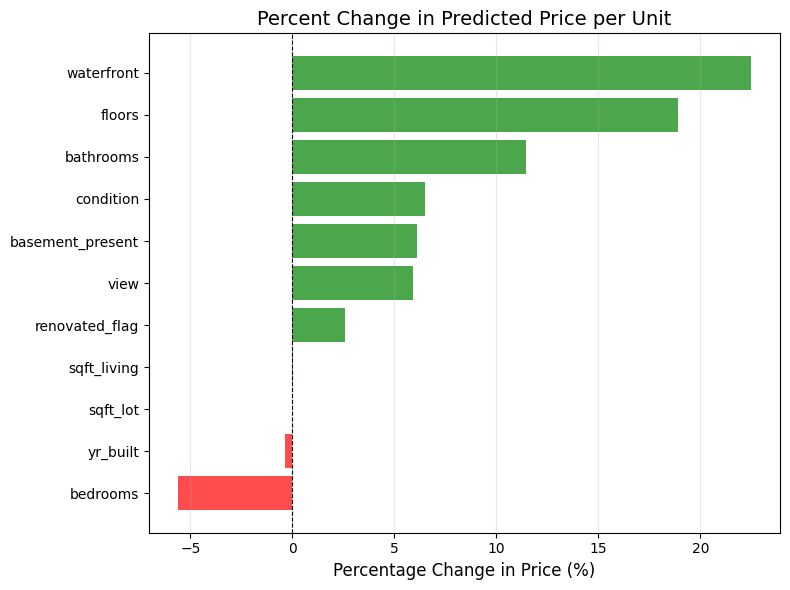

In [42]:
# Visualization: Coefficient plot
coef_plot_df = coef_df[coef_df['Variable'] != 'const'].copy()
coef_plot_df = coef_plot_df.sort_values('% Change in Price')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['red' if x < 0 else 'green' for x in coef_plot_df['% Change in Price']]
ax.barh(coef_plot_df['Variable'], coef_plot_df['% Change in Price'], color=colors, alpha=0.7)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Percentage Change in Price (%)', fontsize=12)
ax.set_title('Percent Change in Predicted Price per Unit', fontsize=14)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Model Limitations

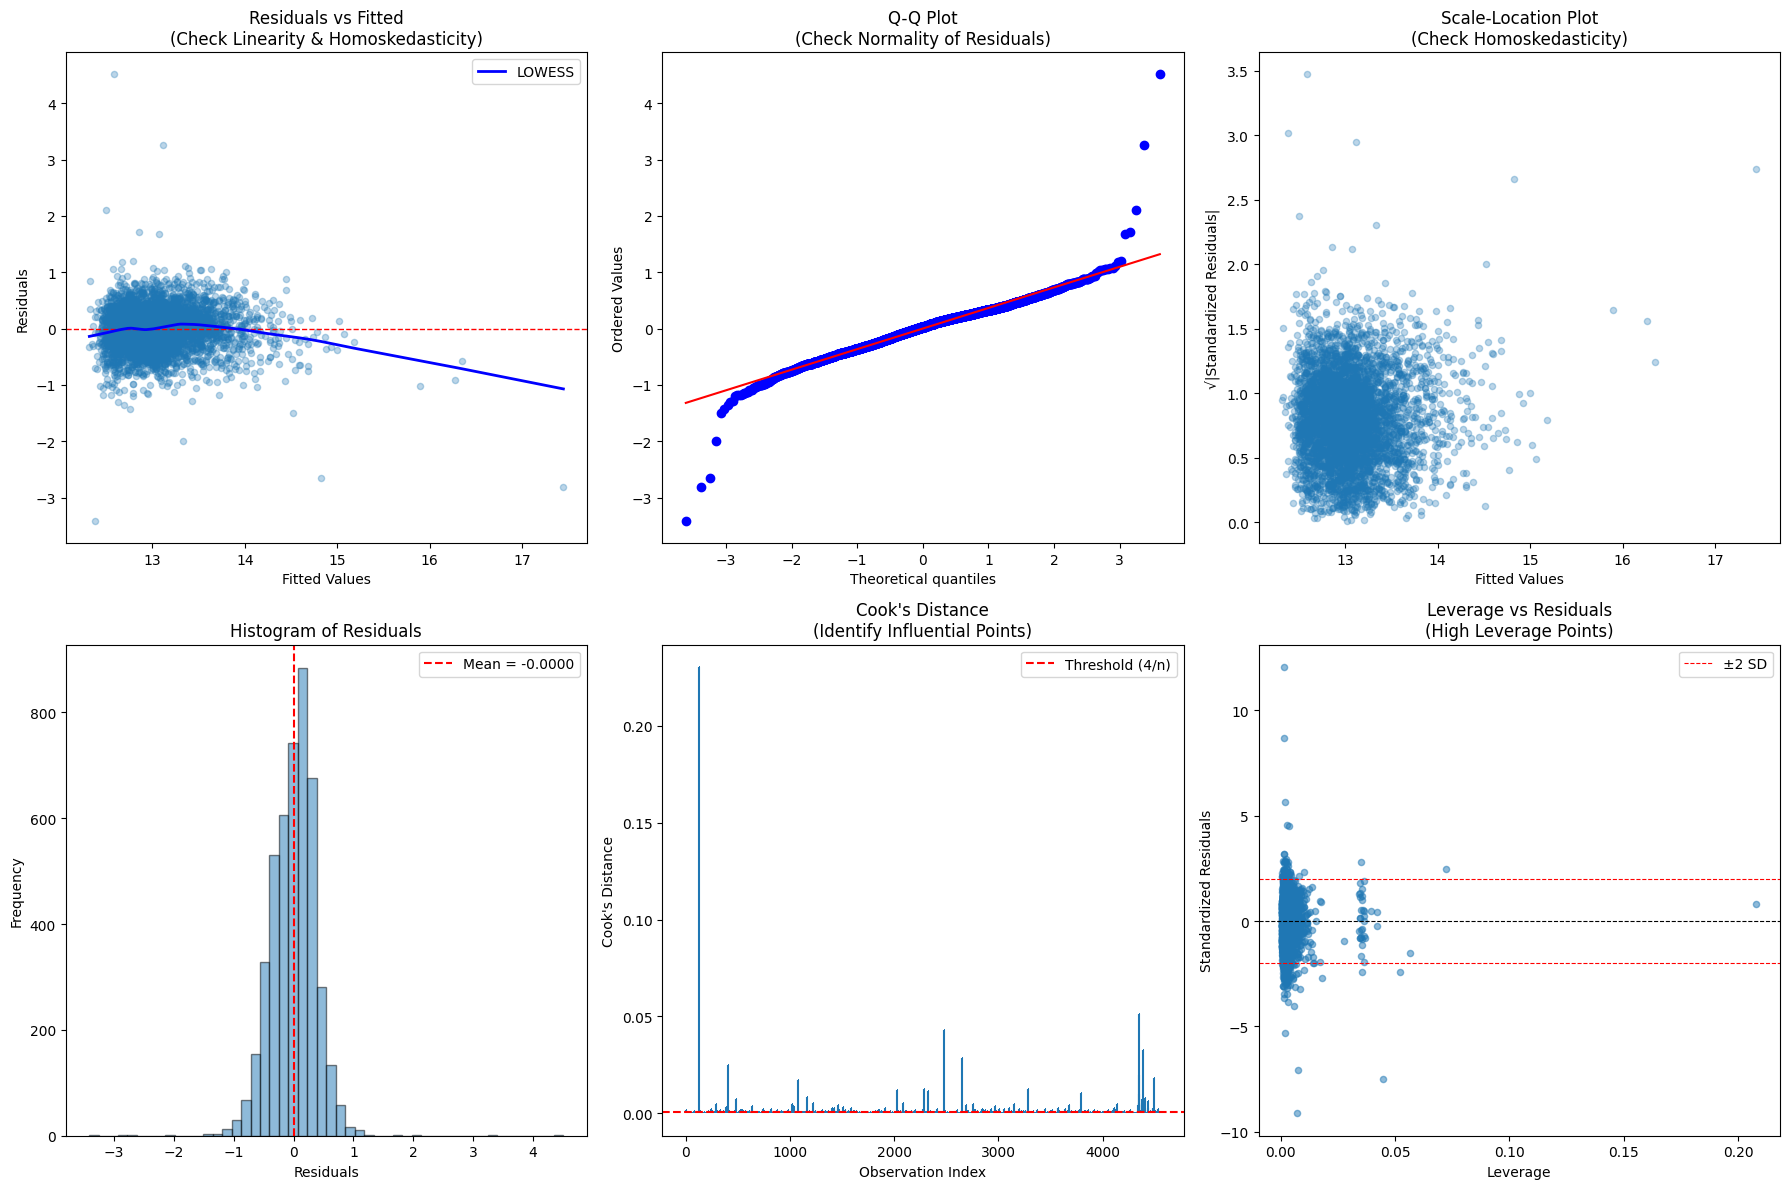

In [43]:
### Model Limitations ###

# Residual diagnostics
residuals = final_model.resid
fitted_values = final_model.fittedvalues
standardized_residuals = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(2, 3, figsize = (18, 12))

# 1. Residuals vs Fitted (Linearity & Homoskedasticity)
axes[0, 0].scatter(fitted_values, residuals, alpha=0.3, s=20)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted\n(Check Linearity & Homoskedasticity)')

# Add LOWESS smoother
from statsmodels.nonparametric.smoothers_lowess import lowess
lowess_result = lowess(residuals, fitted_values, frac=0.3)
axes[0, 0].plot(lowess_result[:, 0], lowess_result[:, 1], color='blue', linewidth=2, label='LOWESS')
axes[0, 0].legend()

# 2. Q-Q Plot (Normality of Residuals)
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot\n(Check Normality of Residuals)')

# 3. Scale-Location (Homoskedasticity)
axes[0, 2].scatter(fitted_values, np.sqrt(np.abs(standardized_residuals)), alpha=0.3, s=20)
axes[0, 2].set_xlabel('Fitted Values')
axes[0, 2].set_ylabel('√|Standardized Residuals|')
axes[0, 2].set_title('Scale-Location Plot\n(Check Homoskedasticity)')

# 4. Residuals Histogram
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.5)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Histogram of Residuals')
axes[1, 0].axvline(residuals.mean(), color='red', linestyle='--', label=f'Mean = {residuals.mean():.4f}')
axes[1, 0].legend()

# 5. Cook's Distance (Influential Points)
from statsmodels.stats.outliers_influence import OLSInfluence
influence = OLSInfluence(final_model)
cooks_dist = influence.cooks_distance[0]

axes[1, 1].stem(range(len(cooks_dist)), cooks_dist, markerfmt=',', basefmt=' ')
axes[1, 1].axhline(4/len(cooks_dist), color='red', linestyle='--', label='Threshold (4/n)')
axes[1, 1].set_xlabel('Observation Index')
axes[1, 1].set_ylabel("Cook's Distance")
axes[1, 1].set_title("Cook's Distance\n(Identify Influential Points)")
axes[1, 1].legend()

# 6. Leverage vs Residuals
leverage = influence.hat_matrix_diag
axes[1, 2].scatter(leverage, standardized_residuals, alpha=0.5, s=20)
axes[1, 2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 2].axhline(2, color='red', linestyle='--', linewidth=0.8, label='±2 SD')
axes[1, 2].axhline(-2, color='red', linestyle='--', linewidth=0.8)
axes[1, 2].set_xlabel('Leverage')
axes[1, 2].set_ylabel('Standardized Residuals')
axes[1, 2].set_title('Leverage vs Residuals\n(High Leverage Points)')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('diagnostic_plots.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
#### Statistical tests for assumptions ####

print("\nDIAGNOSTIC TESTS")

# Breusch-Pagan test for heteroskedasticity
bp_test = het_breuschpagan(residuals, final_model.model.exog)
print(f"\nBreusch-Pagan Test for Heteroskedasticity:")
print(f"  LM Statistic: {bp_test[0]:.4f}")
print(f"  p-value: {bp_test[1]:.4f}")
print(f"  Interpretation: {'Heteroskedasticity detected' if bp_test[1] < 0.05 else 'Homoskedasticity assumption holds'}")

# Jarque-Bera test for normality
jb_test = stats.jarque_bera(residuals)
print(f"\nJarque-Bera Test for Normality:")
print(f"  JB Statistic: {jb_test[0]:.4f}")
print(f"  p-value: {jb_test[1]:.4f}")
print(f"  Interpretation: {'Residuals not normally distributed' if jb_test[1] < 0.05 else 'Normality assumption holds'}")

# Influential points
influential_threshold = 4 / len(cooks_dist)
influential_count = np.sum(cooks_dist > influential_threshold)
print(f"\nInfluential Observations (Cook's D > {influential_threshold:.4f}):")
print(f"  Count: {influential_count} ({100*influential_count/len(cooks_dist):.2f}% of data)")

# VIF check (repeat for final confirmation)
vif_final = pd.DataFrame()
vif_final['Variable'] = X.columns
vif_final['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_final = vif_final[vif_final['Variable'] != 'const']
print(f"\nMulticollinearity Check (VIF):")
print(vif_final.to_string(index=False))
max_vif = vif_final['VIF'].max()
print(f"  Maximum VIF: {max_vif:.2f}")
print(f"  Status: {'✓ No severe multicollinearity' if max_vif < 10 else '✗ Multicollinearity concern'}")


DIAGNOSTIC TESTS

Breusch-Pagan Test for Heteroskedasticity:
  LM Statistic: 62.1277
  p-value: 0.0000
  Interpretation: Heteroskedasticity detected

Jarque-Bera Test for Normality:
  JB Statistic: 14868.2384
  p-value: 0.0000
  Interpretation: Residuals not normally distributed

Influential Observations (Cook's D > 0.0009):
  Count: 214 (4.70% of data)

Multicollinearity Check (VIF):
        Variable      VIF
        bedrooms 1.683644
       bathrooms 3.386276
     sqft_living 3.033445
        sqft_lot 1.073256
          floors 1.737927
      waterfront 1.145605
            view 1.304999
       condition 1.425687
        yr_built 1.907613
  renovated_flag 1.315362
basement_present 1.340209
  Maximum VIF: 3.39
  Status: ✓ No severe multicollinearity


In [45]:
###### Prediction #######

# Train-test split
X_model = X_final
y_model = y_final
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

# Add constant to training and test sets
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Fit model on training data
train_model = sm.OLS(y_train, X_train_const).fit()

# Predictions
y_train_pred = train_model.predict(X_train_const)
y_test_pred = train_model.predict(X_test_const)

# Convert back to original scale
price_train_actual = np.exp(y_train)
price_train_pred = np.exp(y_train_pred)
price_test_actual = np.exp(y_test)
price_test_pred = np.exp(y_test_pred)

def calculate_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    r2   = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
        "MAPE": mape
            }

# Convert back to original scale
price_train_actual = np.exp(y_train)
price_train_pred = np.exp(y_train_pred)
price_test_actual = np.exp(y_test)
price_test_pred = np.exp(y_test_pred)

# Evaluation: price
train_metrics_p = calculate_metrics(price_train_actual, price_train_pred)
test_metrics_p  = calculate_metrics(price_test_actual,  price_test_pred)
train_metrics = calculate_metrics(y_train, y_train_pred)
test_metrics  = calculate_metrics(y_test,  y_test_pred)

# Display results
metrics_df = pd.DataFrame({
    'Metric': ['RMSE ($)', 'MAE ($)', 'R² (log price)', 'MAPE (%)'],
    'In-Sample (Train)': [
        f"${train_metrics_p['RMSE']:,.0f}",
        f"${train_metrics_p['MAE']:,.0f}",
        f"{train_metrics['R²']:.4f}",
        f"{train_metrics_p['MAPE']:.2f}%"
    ],
    'Out-of-Sample (Test)': [
        f"${test_metrics_p['RMSE']:,.0f}",
        f"${test_metrics_p['MAE']:,.0f}",
        f"{test_metrics['R²']:.4f}",
        f"{test_metrics_p['MAPE']:.2f}%"
    ]
})

print("\nPREDICTIVE PERFORMANCE COMPARISON")
print(metrics_df.to_string(index=False))
print("\nInterpretation:")
print(f"  • Model explains {test_metrics['R²']*100:.1f}% of the variation in log price on unseen data")
print(f"  • Average prediction error: ${test_metrics_p['MAE']:,.0f} ({test_metrics_p['MAPE']:.1f}%)")
print(f"  • Minimal overfitting: {'✓' if abs(train_metrics['R²'] - test_metrics['R²']) < 0.05 else '✗'}")


PREDICTIVE PERFORMANCE COMPARISON
        Metric In-Sample (Train) Out-of-Sample (Test)
      RMSE ($)          $553,904           $1,421,361
       MAE ($)          $164,235             $209,170
R² (log price)            0.5298               0.4995
      MAPE (%)            30.92%               33.78%

Interpretation:
  • Model explains 50.0% of the variation in log price on unseen data
  • Average prediction error: $209,170 (33.8%)
  • Minimal overfitting: ✓


In [46]:
##### APPLY HC3 #####

# 1) Before Robust
print(final_model.summary())

# 2) after applying HC3 robust standard errors 
final_model_robust = final_model.get_robustcov_results(cov_type='HC3')
print(final_model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     454.8
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        19:57:54   Log-Likelihood:                -1982.2
No. Observations:                4549   AIC:                             3988.
Df Residuals:                    4537   BIC:                             4065.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               18.5464      0.518  

In [47]:
### Apply WLS ###

y = pd.Series(final_model.model.endog, index=final_model.fittedvalues.index, name=final_model.model.endog_names)      # Dependent variable used in the original OLS model
X_full = pd.DataFrame(final_model.model.exog, index=final_model.fittedvalues.index, columns=final_model.model.exog_names)  # Full design matrix (all regressors)

# 1) Extract fitted values from the OLS model
fitted = final_model.fittedvalues

# 2) Assume heteroscedasticity: variance increases with fitted values.
#    Use weights proportional to 1 / fitted^2.
#    Add a small constant to avoid division by zero and extreme weights.
weights = 1 / (fitted**2 + 1e-6)

# 3) Fit a Weighted Least Squares (WLS) model using the custom weights
wls_model = sm.WLS(y, X_full, weights=weights).fit()

print(wls_model.summary())

                            WLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.515
Model:                            WLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     437.5
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        19:57:54   Log-Likelihood:                -1971.8
No. Observations:                4549   AIC:                             3968.
Df Residuals:                    4537   BIC:                             4045.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               18.6365      0.519  

In [48]:
# Define the final set of features used in the regression model
feature_cols = [
    'sqft_living', 'yr_built', 'floors', 'view',
    'bathrooms', 'bedrooms', 'condition',
    'basement_present', 'sqft_lot', 'waterfront',
    'renovated_flag'
]

# ----------------------------------------------------------
# 1) Trim extreme price values (remove top and bottom 1%)
# Purpose:
#   - Reduce the influence of extreme outliers on the regression.
#   - Improve model stability and reduce heavy-tailed residual behavior.
# ----------------------------------------------------------
lower_cap = df_model['price'].quantile(0.01)
upper_cap = df_model['price'].quantile(0.99)

df_trim = df_model[
    (df_model['price'] >= lower_cap) &
    (df_model['price'] <= upper_cap)
]

print("Before trim:", df_model.shape)
print("After  trim:", df_trim.shape)

# ----------------------------------------------------------
# 2) Re-build the design matrix (X) and target variable (y)
# Purpose:
#   - Use the trimmed dataset to construct features for the model.
#   - Do NOT include the constant term here; add it explicitly later.
# ----------------------------------------------------------
y_trim = np.log(df_trim['price']).rename('log_price')  # log-transform the target
X_trim = df_trim[feature_cols]          # select model features

# ----------------------------------------------------------
# 3) Fit OLS regression on the trimmed dataset
# Purpose:
#   - Evaluate whether removing extreme observations improves
#     linearity, homoskedasticity, and overall model performance.
# ----------------------------------------------------------
X_trim_const = sm.add_constant(X_trim)  # add intercept
model_trim = sm.OLS(y_trim, X_trim_const).fit()

print(model_trim.summary())

Before trim: (4549, 13)
After  trim: (4458, 13)
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     440.2
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        19:57:54   Log-Likelihood:                -1516.1
No. Observations:                4458   AIC:                             3056.
Df Residuals:                    4446   BIC:                             3133.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [49]:
# --------------------------------------------------------------
# Robust Regression using Huber's M-estimator (RLM)
#
# Purpose:
#   - Reduce sensitivity to outliers and influential points.
#   - Compare coefficient stability against standard OLS.
#   - Provide a robustness check when normality or homoskedasticity
#     assumptions are violated, which is common in housing price data.
# --------------------------------------------------------------

from statsmodels.robust.robust_linear_model import RLM
from statsmodels.robust.norms import HuberT

# Extract the dependent variable and design matrix from the OLS model
# y     = log(price)
# X_full = all predictors including the constant term
y = pd.Series(final_model.model.endog, index=final_model.fittedvalues.index, name=final_model.model.endog_names)
X_full = pd.DataFrame(final_model.model.exog, index=final_model.fittedvalues.index, columns=final_model.model.exog_names)

# Fit a robust linear model using Huber's T norm
# HuberT reduces the influence of observations with large residuals
rlm_model = RLM(y, X_full, M=HuberT())
rlm_results = rlm_model.fit()

# Display robust regression results
print(rlm_results.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:              log_price   No. Observations:                 4549
Model:                            RLM   Df Residuals:                     4537
Method:                          IRLS   Df Model:                           11
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 08 Oct 2026                                         
Time:                        19:57:54                                         
No. Iterations:                    20                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               19.9004      0.487  

In [50]:
from statsmodels.stats.outliers_influence import OLSInfluence

# --------------------------------------------------------------
# 1) Compute influence measures from the fitted OLS model
# Purpose:
#   - Identify observations that have a disproportionately large
#     impact on the regression estimates.
#   - Cook's distance combines leverage and residual size to flag
#     influential outliers.
# --------------------------------------------------------------
influence = OLSInfluence(final_model)
cooks_dist = influence.cooks_distance[0]

# --------------------------------------------------------------
# 2) Convert Cook's distance values into a labeled Series
# Purpose:
#   - Attach row indices so we can directly filter out influential
#     observations from the dataset.
# --------------------------------------------------------------
cooks_series = pd.Series(cooks_dist, index=final_model.model.data.row_labels)

# --------------------------------------------------------------
# 3) Set the threshold for influential points (4/n rule)
# Purpose:
#   - A common rule of thumb: observations with Cook's D > 4/n
#     are considered potentially influential.
# --------------------------------------------------------------
n = len(cooks_series)
threshold = 4 / n

high_influence_idx = cooks_series[cooks_series > threshold].index
print(f"High influence points: {len(high_influence_idx)} ({len(high_influence_idx)/n*100:.2f}%)")

# --------------------------------------------------------------
# 4) Remove high-influence observations and rebuild X and y
# Purpose:
#   - Evaluate how sensitive our regression coefficients are to
#     influential observations.
#   - If results remain stable, the model is robust.
# --------------------------------------------------------------
X_noinf = X.loc[~X.index.isin(high_influence_idx)]
y_noinf = y_model.loc[~y_model.index.isin(high_influence_idx)]  # y_model = log(price)

X_noinf_const = sm.add_constant(X_noinf)

# --------------------------------------------------------------
# 5) Re-fit the OLS model on the cleaned dataset
# Purpose:
#   - Compare coefficient estimates, significance levels,
#     and model fit (R²) before and after removing influential points.
# --------------------------------------------------------------
model_noinf = sm.OLS(y_noinf, X_noinf_const).fit()

print(model_noinf.summary())

High influence points: 214 (4.70%)
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     575.3
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        19:57:54   Log-Likelihood:                -1159.6
No. Observations:                4335   AIC:                             2343.
Df Residuals:                    4323   BIC:                             2420.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const

In [51]:
########### SENSITIVITY ANALYSIS ################

# --------------------------------------------------------------------------------
# Helper function: Predict price using the log-price OLS model
# Purpose:
#   - Convert a dictionary of feature values into a single-row DataFrame
#   - Add constant term
#   - Predict log(price) using the OLS model
#   - Convert prediction back to dollar scale via exp()
# --------------------------------------------------------------------------------
def predict_price(feature_dict, model):
    row = pd.DataFrame([feature_dict])
    row_const = sm.add_constant(row, has_constant='add')
    log_pred = model.predict(row_const)[0]
    return float(np.exp(log_pred))


# --------------------------------------------------------------------------------
# 1) Define the baseline property for sensitivity analysis
# Purpose:
#   - Establish a reference home against which individual feature effects
#     (waterfront, view, renovation, etc.) can be compared
# --------------------------------------------------------------------------------
baseline = {
    'sqft_living'     : 1920,
    'yr_built'        : 1990,
    'floors'          : 2.0,
    'view'            : 0,
    'bathrooms'       : 2.25,
    'bedrooms'        : 3,
    'condition'       : 3,
    'basement_present': 0,
    'sqft_lot'        : float(df_model['sqft_lot'].median()),
    'waterfront'      : 0,
    'renovated_flag'  : 0
}

# Infer approximate “current year” based on dataset
data_year = int(df_model['yr_built'].max())
baseline_age = data_year - baseline['yr_built']

baseline_price = predict_price(baseline, final_model)


# --------------------------------------------------------------------------------
# 2) Waterfront effect (0 → 1)
# Purpose:
#   - Compute price difference between the same home with and without waterfront
# --------------------------------------------------------------------------------
no_waterfront_price  = predict_price({**baseline, 'waterfront': 0}, final_model)
waterfront_price     = predict_price({**baseline, 'waterfront': 1}, final_model)
waterfront_premium   = (waterfront_price / no_waterfront_price - 1) * 100


# --------------------------------------------------------------------------------
# 3) View quality (0 → 4)
# Purpose:
#   - Estimate price change as view rating improves
# --------------------------------------------------------------------------------
view_prices = {}
for v in range(0, 5):
    view_prices[v] = predict_price({**baseline, 'view': v}, final_model)

view_min = view_prices[0]
view_max = view_prices[4]
view_each_step = (view_prices[1] / view_prices[0] - 1) * 100


# --------------------------------------------------------------------------------
# 4) Renovation effect (renovated_flag: 0 → 1)
# Purpose:
#   - Estimate the price premium associated with renovation
# --------------------------------------------------------------------------------
not_renovated_price = predict_price({**baseline, 'renovated_flag': 0}, final_model)
renovated_price     = predict_price({**baseline, 'renovated_flag': 1}, final_model)

renov_premium_pct = (renovated_price / not_renovated_price - 1) * 100
renov_premium_abs = renovated_price - not_renovated_price


# --------------------------------------------------------------------------------
# 5) Living space effect (sqft_living: 1,000 → 4,000)
# Purpose:
#   - Show how predicted price changes as living area increases
# --------------------------------------------------------------------------------
sqft_grid = [1000, 2000, 3000, 4000]
sqft_prices = {
    s: predict_price({**baseline, 'sqft_living': s}, final_model)
    for s in sqft_grid
}
sqft_min = sqft_prices[min(sqft_grid)]
sqft_max = sqft_prices[max(sqft_grid)]


# --------------------------------------------------------------------------------
# 6) Bathroom count effect (1.5 → 4)
# Purpose:
#   - Evaluate the price sensitivity to the number of bathrooms
# --------------------------------------------------------------------------------
bath_15_price = predict_price({**baseline, 'bathrooms': 1.5}, final_model)
bath_4_price  = predict_price({**baseline, 'bathrooms': 4.0}, final_model)


# --------------------------------------------------------------------------------
# 7) Property age effect (new home vs. 100-year-old home)
# Purpose:
#   - Compare predicted price for a newly built home and for a 100-year-old home
# --------------------------------------------------------------------------------
new_house_price = predict_price({**baseline, 'yr_built': data_year}, final_model)
old_100y_price  = predict_price({**baseline, 'yr_built': data_year - 100}, final_model)


# --------------------------------------------------------------------------------
# 8) Print formatted results for slide copy-paste
# Purpose:
#   - Produce human-readable text blocks that match presentation-ready format
# --------------------------------------------------------------------------------

print("=" * 80)
print("SENSITIVITY ANALYSIS")
print("=" * 80)

print(
    f"\nBaseline Property: 3b/2.25b, {baseline['sqft_living']:,.0f} sqft, "
    f"{baseline_age} years old, Condition: Average (3), "
    f"No view, No waterfront  |  Predicted Price: ${baseline_price:,.0f}"
)

print("\n" + "-" * 80)
print("Waterfront Effect:")
print(f"  Without waterfront: ${no_waterfront_price:,.0f}")
print(f"  With waterfront   : ${waterfront_price:,.0f}")
print(f"  Premium           : +{waterfront_premium:,.1f}% "
      f"(+${waterfront_price - no_waterfront_price:,.0f})")

print("\nView Quality:")
print(f"  No view (0)   : ${view_min:,.0f}")
print(f"  Excellent (4) : ${view_max:,.0f}")
print(f"  Range         : ~${view_min:,.0f} → ~${view_max:,.0f}")
print(f"  Each rating +1: ≈ +{view_each_step:,.1f}%")

print("\n" + "-" * 80)
print("Renovation:")
print(f"  Not renovated: ${not_renovated_price:,.0f}")
print(f"  Renovated    : ${renovated_price:,.0f}")
print(f"  Premium      : +{renov_premium_pct:,.1f}% "
      f"(+${renov_premium_abs:,.0f})")

print("\nLiving Space:")
print(f"  1,000 sqft → 4,000 sqft: "
      f"~${sqft_min:,.0f} → ~${sqft_max:,.0f}")
print("  Strong positive relationship with price.")

print("\n" + "-" * 80)
print("Bathrooms:")
print(f"  1.5 baths → 4 baths: ~${bath_15_price:,.0f} → ~${bath_4_price:,.0f}")
print("  Each added bathroom is associated with about +11% in predicted price.")

print("\nProperty Age:")
print(f"  New vs 100-year-old: ~${new_house_price:,.0f} → ~${old_100y_price:,.0f}")
print("  Older homes are predicted higher at the same size and condition.")

print("\n" + "-" * 80)
print("Implications (associations, not causal effects):")
print("  Sellers   : Highlight waterfront and views; maintain condition.")
print("  Buyers    : Prioritize living space and bathrooms over bedrooms.")
print("  Developers: Maximize floor space and orientation for views.")
print("-" * 80)


SENSITIVITY ANALYSIS

Baseline Property: 3b/2.25b, 1,920 sqft, 24 years old, Condition: Average (3), No view, No waterfront  |  Predicted Price: $430,955

--------------------------------------------------------------------------------
Waterfront Effect:
  Without waterfront: $430,955
  With waterfront   : $527,879
  Premium           : +22.5% (+$96,924)

View Quality:
  No view (0)   : $430,955
  Excellent (4) : $542,288
  Range         : ~$430,955 → ~$542,288
  Each rating +1: ≈ +5.9%

--------------------------------------------------------------------------------
Renovation:
  Not renovated: $430,955
  Renovated    : $442,047
  Premium      : +2.6% (+$11,092)

Living Space:
  1,000 sqft → 4,000 sqft: ~$317,742 → ~$858,369
  Strong positive relationship with price.

--------------------------------------------------------------------------------
Bathrooms:
  1.5 baths → 4 baths: ~$397,281 → ~$521,048
  Each added bathroom is associated with about +11% in predicted price.

Property A

## Check added in October 2026

The test RMSE in the prediction table is much larger than the training RMSE, while MAE and R-squared change much less. This cell shows how much of the test RMSE comes from a single home.

In [52]:
sq_err = (price_test_pred - price_test_actual) ** 2
worst = sq_err.idxmax()
print(f"Largest error: actual ${price_test_actual[worst]:,.0f}, predicted ${price_test_pred[worst]:,.0f}, "
      f"living area {X_test.loc[worst, 'sqft_living']:,} sq ft")
print(f"Share of the test squared error from this one home: {sq_err[worst] / sq_err.sum():.1%}")
print(f"Test RMSE without it: ${np.sqrt(sq_err.drop(worst).mean()):,.0f}")

Largest error: actual $2,280,000, predicted $44,150,969, living area 13,540 sq ft


Share of the test squared error from this one home: 95.4%
Test RMSE without it: $306,270
